# M1: Sklearn — a *complete* workflow on Titanic

A realistic ML workflow built around the six-stage `BasePipeline`:

1. **EDA** on the raw data — understand the problem before modelling.
2. **Feature engineering** — turn what EDA reveals into new features.
3. **Three-way split** (70 / 15 / 15) — by *composing the library's two-way split twice*.
4. **Pipeline with HPO** — Optuna runs *inside* `build_model()`; the notebook just calls `run()`.
5. **Diagnostics** — Optuna trial plots, generalization-gap bars, confusion/ROC/PR, learning curve.

**Prerequisites:** `scikit-learn`, `matplotlib`, `optuna` (`uv sync --dev`).

In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support

from pipeline.config import Config
from pipeline.data.csv_source import CsvDataSource
from pipeline.data.split import train_test_split
from pipeline.data.utils import collect_arrays
from pipeline.evaluation.metrics import (
    Metrics, accuracy, precision, recall, f1_score, confusion_matrix)
from pipeline.pipeline import BasePipeline, PipelineState
from pipeline.adapters.sklearn_adapter import SklearnModel, StubLoss, StubOptimizer

RNG_SEED = 42
np.random.seed(RNG_SEED)
print('Imports OK')

Imports OK


## 1. Exploratory Data Analysis (raw data)

We explore the **raw** Titanic frame before any encoding or scaling.

In [2]:
titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
raw = titanic.data.copy()
raw['survived'] = titanic.target.astype(int)
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (1309, 14)


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


### 1.1 Structure & missing values

In [3]:
info = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'n_missing': raw.isna().sum(),
    'pct_missing': (raw.isna().mean() * 100).round(1),
    'n_unique': raw.nunique(),
})
info.sort_values('pct_missing', ascending=False)

,dtype,n_missing,pct_missing,n_unique
body,float64,1188,90.8,121
cabin,str,1014,77.5,186
boat,str,823,62.9,27
home.dest,str,564,43.1,369
age,float64,263,20.1,98
embarked,category,2,0.2,3
fare,float64,1,0.1,281
parch,int64,0,0.0,8
sex,category,0,0.0,2
name,str,0,0.0,1307


**Read:** `cabin` (77.5% missing), `boat` (62.9%), `body` (90.8%), and `home.dest` (43.1%)
are too sparse to impute reliably. `age` (20.1%) and `fare` (0.1%) are salvageable.

**Decision:** drop the near-empty columns outright (they never appear in `feature_cols`
in §2) rather than engineering missingness flags for them; median-impute `age`/`fare`
instead of dropping rows.

In [4]:
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
name,1309,1307,"Connolly, Miss. Kate",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1046.0,NaN,NaN,NaN,29.881135,14.4135,0.1667,21.0,28.0,39.0,80.0
sibsp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
ticket,1309,929,CA. 2343,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
embarked,1307,3,S,914,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Target balance

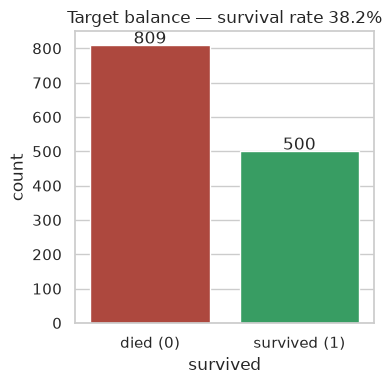

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(x='survived', data=raw, palette=['#c0392b', '#27ae60'], ax=ax)
ax.set_xticklabels(['died (0)', 'survived (1)'])
ax.set_title(f"Target balance — survival rate {raw['survived'].mean():.1%}")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                ha='center')
plt.tight_layout()

**Read:** ~38% survived — moderate imbalance. Not severe enough to need resampling, but
enough that a model predicting "died" for everyone would already score ~62% accuracy.

**Decision:** track F1 alongside accuracy throughout, and let the HPO search in §4 tune
`class_weight` (`None` vs `'balanced'`) rather than assuming one is correct.

### 1.3 Survival rate by categorical features

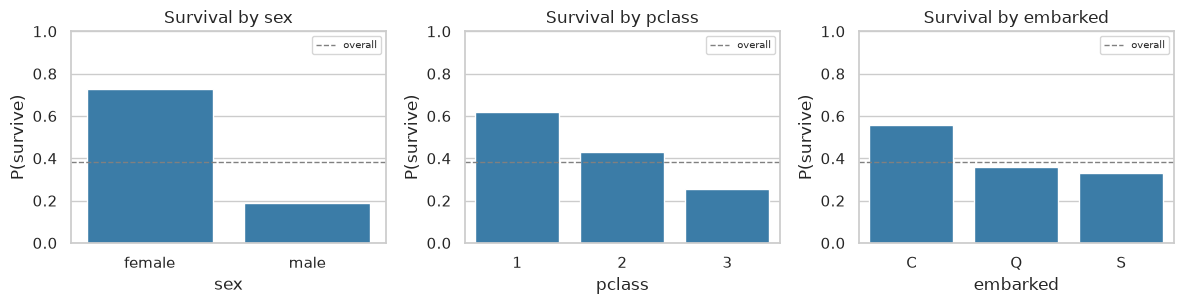

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
overall = raw['survived'].mean()
for ax, col in zip(axes, ['sex', 'pclass', 'embarked']):
    sns.barplot(x=col, y='survived', data=raw, color='#2980b9', errorbar=None, ax=ax)
    ax.axhline(overall, ls='--', c='gray', lw=1, label='overall')
    ax.set_title(f'Survival by {col}'); ax.set_ylim(0, 1)
    ax.set_ylabel('P(survive)'); ax.legend(fontsize=7)
plt.tight_layout()

**Read:** `sex` shows the widest split from the ~38% baseline (women survived far more),
`pclass` is monotonic (1st > 2nd > 3rd), `embarked` differs but less sharply than the
other two.

**Decision:** all three are strong, cheap-to-encode signals — keep them as features in
§2 rather than dropping any for parsimony.

### 1.4 Age & fare distributions, split by survival

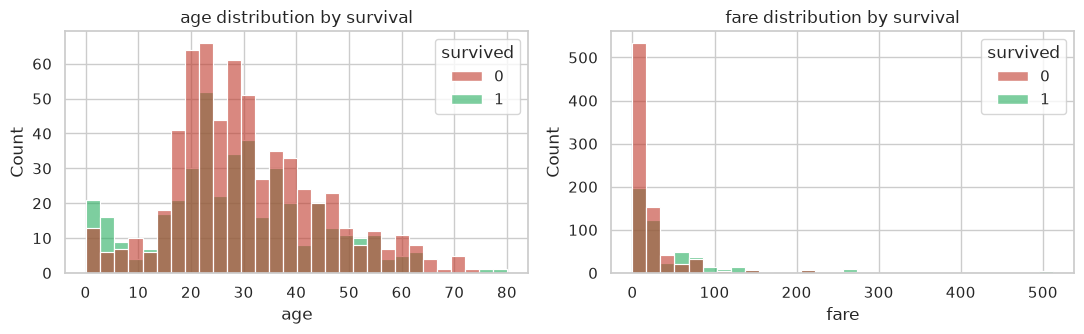

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_df = raw.copy()
plot_df['age'] = pd.to_numeric(plot_df['age'], errors='coerce')
plot_df['fare'] = pd.to_numeric(plot_df['fare'], errors='coerce')
for ax, col in zip(axes, ['age', 'fare']):
    sns.histplot(data=plot_df, x=col, hue='survived', bins=30, alpha=0.6,
                 palette={0: '#c0392b', 1: '#27ae60'}, ax=ax)
    ax.set_title(f'{col} distribution by survival')
plt.tight_layout()

**Read:** `fare` is heavily right-skewed, with survivors skewed toward higher fares.
`age` distributions overlap more, with a mild survival bump for young children.

**Decision:** skew plus very different raw scales (`fare` spans 0-512, `age` spans 0-80)
mean both need `StandardScaler` in §2 — Logistic Regression is scale-sensitive.

### 1.5 Correlation matrix

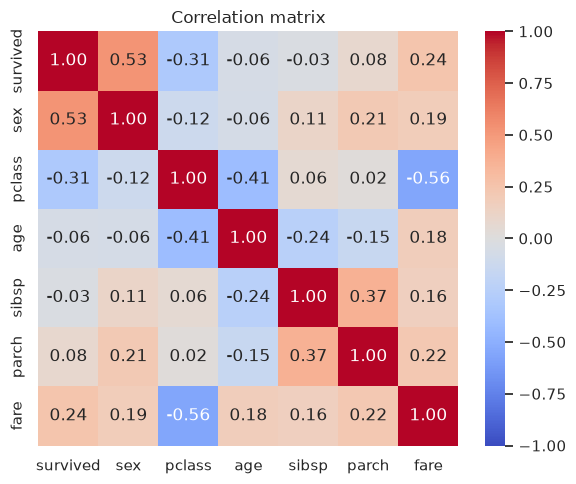

In [8]:
num = raw.copy()
num['sex'] = (num['sex'] == 'female').astype(int)
for c in ['age', 'fare', 'sibsp', 'parch', 'pclass']:
    num[c] = pd.to_numeric(num[c], errors='coerce')
corr = num[['survived', 'sex', 'pclass', 'age', 'sibsp', 'parch', 'fare']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt='.2f', ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()

**Read:** `sex` and `pclass`/`fare` correlate most strongly with `survived`. `pclass` and
`fare` also correlate with *each other* (~-0.55) — expected, since cabin class largely
sets ticket price.

**Decision:** this multicollinearity mainly hurts coefficient interpretability, not
predictive power — keep both features and let the HPO search's `C` (regularization
strength) in §4 absorb the redundancy instead of manually dropping one.

### 1.6 Scatter matrix (color = survival)

Text(0.5, 1.02, 'Scatter matrix (color = survival)')

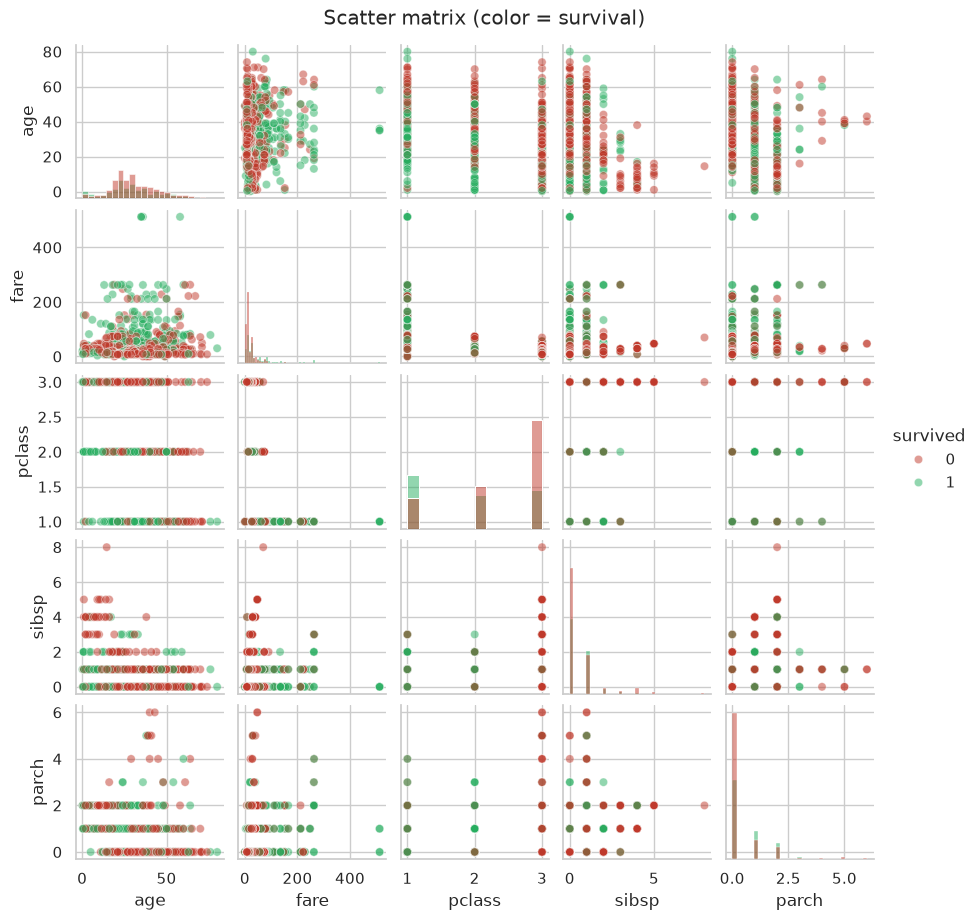

In [9]:
sm_cols = ['age', 'fare', 'pclass', 'sibsp', 'parch']
sm_df = num[sm_cols + ['survived']].dropna()
sns.pairplot(sm_df, vars=sm_cols, hue='survived',
             palette={0: '#c0392b', 1: '#27ae60'}, diag_kind='hist',
             plot_kws=dict(alpha=0.5), height=1.8)
plt.suptitle('Scatter matrix (color = survival)', y=1.02)

**Read:** no pairwise projection here shows a strongly nonlinear boundary or clean
cluster split — survivors (orange) and non-survivors (blue) mostly overlap in 2D.

**Decision:** no evidence yet that we need polynomial/interaction features or a
nonlinear model — a linear model (Logistic Regression) is a reasonable baseline.

### 1.7 Feature-engineering exploration

Three candidate features: `family_size`, `is_alone`, and `title` extracted from the name.
We check whether each separates survival before committing to it.

               mean  count
title_grp                 
Master     0.508197     61
Miss       0.676923    260
Mr         0.162483    757
Mrs        0.786802    197
Other      0.441176     34


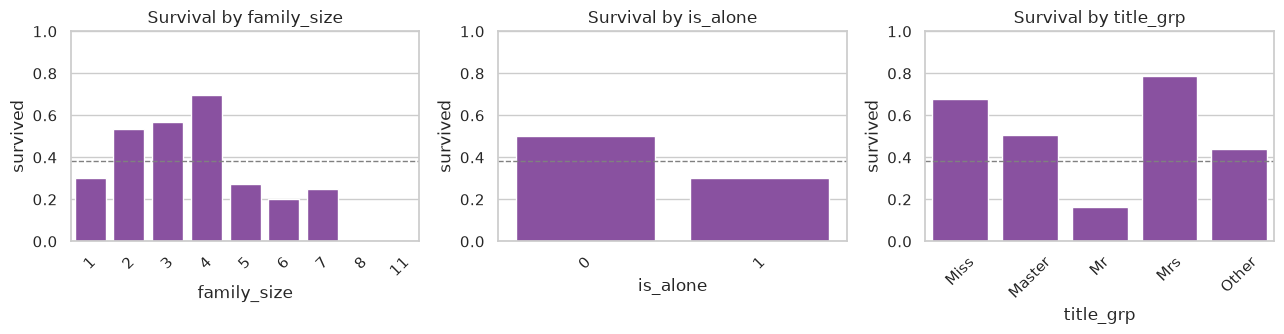

In [10]:
fe = raw.copy()
fe['family_size'] = (pd.to_numeric(fe['sibsp'], errors='coerce')
                     + pd.to_numeric(fe['parch'], errors='coerce') + 1)
fe['is_alone'] = (fe['family_size'] == 1).astype(int)
title = fe['name'].str.extract(r',\s*([^\.]+)\.')[0].str.strip()
fe['title_grp'] = title.where(title.isin(['Mr', 'Mrs', 'Miss', 'Master']), 'Other')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
overall = fe['survived'].mean()
for ax, col in zip(axes, ['family_size', 'is_alone', 'title_grp']):
    sns.barplot(x=col, y='survived', data=fe, color='#8e44ad', errorbar=None, ax=ax)
    ax.axhline(overall, ls='--', c='gray', lw=1)
    ax.set_title(f'Survival by {col}'); ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

print(fe.groupby('title_grp')['survived'].agg(['mean', 'count']))

**Read:** `is_alone` and small families (`family_size` 2-4) survive more than solo
travelers or large families; `title_grp` separates sharply (`Mrs`/`Miss` far above `Mr`),
folding sex + age + marital status into one categorical.

**Decision:** all three candidate features pass the "does it separate the target?" check
— commit them in §2 alongside the raw columns.

### 1.8 Outliers in age & fare

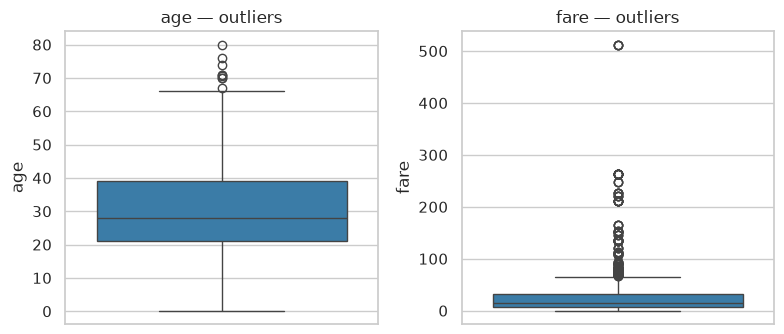

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
box_df = raw.copy()
for col, ax in zip(['age', 'fare'], axes):
    box_df[col] = pd.to_numeric(box_df[col], errors='coerce')
    sns.boxplot(y=box_df[col].dropna(), color='#2980b9', ax=ax)
    ax.set_title(f'{col} — outliers'); ax.set_ylabel(col)
plt.tight_layout()

**Read:** `fare` has a long tail of high-value outliers (luxury first-class tickets);
`age` has few extreme values.

**Decision:** kept as-is rather than clipped/log-transformed — `StandardScaler` plus the
L1/L2-regularized Logistic Regression from §4's HPO search tolerates this well enough,
and simplicity matters more than robustness for a teaching baseline. (A production
pipeline would likely log-transform `fare`.)

## 2. Preprocessing + feature engineering

The engineered features (`family_size`, `is_alone`, `title`) join the base columns.

In [12]:
df = raw.copy()
df['family_size'] = (pd.to_numeric(df['sibsp'], errors='coerce')
                     + pd.to_numeric(df['parch'], errors='coerce') + 1)
df['is_alone'] = (df['family_size'] == 1).astype(int)
title = df['name'].str.extract(r',\s*([^\.]+)\.')[0].str.strip()
df['title'] = title.where(title.isin(['Mr', 'Mrs', 'Miss', 'Master']), 'Other')

feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
                'embarked', 'family_size', 'is_alone', 'title']
df = df[feature_cols + ['survived']].copy()

for col in ['sex', 'embarked', 'title']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
for col in ['age', 'fare', 'sibsp', 'parch', 'pclass', 'family_size']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())
df = df.fillna(0)

X = df[feature_cols].to_numpy(dtype=np.float64)
y = df['survived'].to_numpy(dtype=np.int64)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
print('Design matrix:', X_scaled.shape)
print('Features:', feature_cols)

Design matrix: (1309, 10)
Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone', 'title']


## 3. Three-way split — composing the library's two-way split

`train_test_split` only does a two-way split. Composing it twice gives 70 / 15 / 15:

```
source ──split(0.85)──▶ (temp 85%, test 15%)
temp   ──split(0.82)──▶ (train 70%, val 15%)
```

The **test** stream is frozen here and never touched during tuning.

In [13]:
import tempfile, os
tmpdir = tempfile.mkdtemp()

full_csv = os.path.join(tmpdir, 'titanic_scaled.csv')
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df['survived'] = y
scaled_df.to_csv(full_csv, index=False)

source = CsvDataSource(full_csv, batch_size=64, target_column='survived',
                       shuffle=True, seed=RNG_SEED)
temp_stream, test_stream = train_test_split(source, train_ratio=0.85, seed=RNG_SEED)
train_stream, val_stream = train_test_split(temp_stream, train_ratio=0.8235, seed=RNG_SEED)

X_train, y_train = collect_arrays(train_stream)
X_val,   y_val   = collect_arrays(val_stream)
X_test,  y_test  = collect_arrays(test_stream)
y_train = y_train.astype(int)
y_val   = y_val.astype(int)
y_test  = y_test.astype(int)

# Write train and test CSVs for the pipeline to read
def _dump(path, X_arr, y_arr):
    d = pd.DataFrame(X_arr, columns=feature_cols)
    d['survived'] = y_arr
    d.to_csv(path, index=False)

train_csv = os.path.join(tmpdir, 'train.csv'); _dump(train_csv, X_train, y_train)
test_csv  = os.path.join(tmpdir, 'test.csv');  _dump(test_csv,  X_test,  y_test)

n = len(X_train) + len(X_val) + len(X_test)
print(f'train {len(X_train):4d} ({len(X_train)/n:.0%})  |  '
      f'val {len(X_val):4d} ({len(X_val)/n:.0%})  |  '
      f'test {len(X_test):4d} ({len(X_test)/n:.0%})')

train  915 (70%)  |  val  197 (15%)  |  test  197 (15%)


## 4. Pipeline with HPO inside `build_model()`

Optuna belongs inside the pipeline, not in the notebook. `build_model()` runs the
hyperparameter search using the train/val arrays, stores the study on `self` for
later inspection, then wires up the tuned estimator as the stage's model.

The notebook's job is just: `pipeline.run('train')`.

In [14]:
config = Config(batch_size=128, num_epochs=1, seed=RNG_SEED,
                output_dir=os.path.join(tmpdir, 'out'),
                task_name='titanic-sklearn-hpo')


class TitanicSklearnPipeline(BasePipeline):
    """Six-stage pipeline for Titanic.

    Optuna HPO runs inside build_model() so the notebook only calls run().
    The fitted study is stored on self.study for post-run inspection.
    """

    def load_data(self, state: PipelineState) -> None:
        state.data_stream = CsvDataSource(
            train_csv, batch_size=config.batch_size,
            target_column='survived', shuffle=True)
        state.val_data_stream = CsvDataSource(
            test_csv, batch_size=config.batch_size,
            target_column='survived', shuffle=False)

    def build_model(self, state: PipelineState) -> None:
        # Imported here rather than at notebook top: optuna is an implementation
        # detail of *this* build_model() (HPO strategy), not of the pipeline core,
        # which never depends on optuna (see closing "Key insight" cell).
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)

        def objective(trial):
            params = dict(
                penalty=trial.suggest_categorical('penalty', ['l1', 'l2']),
                C=trial.suggest_float('C', 1e-3, 1e2, log=True),
                solver=trial.suggest_categorical('solver', ['liblinear', 'saga']),
                class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
            )
            est = LogisticRegression(**params, max_iter=2000, random_state=config.seed)
            est.fit(X_train, y_train)
            return f1_score(y_val, est.predict(X_val))

        self.study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=config.seed),
        )
        self.study.optimize(objective, n_trials=100, show_progress_bar=True)

        best = self.study.best_params
        print(f'HPO done — best val F1: {self.study.best_value:.4f}')
        print(f'Best params: {best}')

        state.model = SklearnModel(LogisticRegression(**best, max_iter=2000, random_state=config.seed))
        state.loss_fn = StubLoss()
        state.optimizer = StubOptimizer()
        state.metrics = Metrics(accuracy=accuracy, precision=precision, recall=recall, f1=f1_score)

    def train(self, state: PipelineState) -> None:
        X, yy = collect_arrays(state.data_stream)
        state.model._estimator.fit(X, yy.astype(int))
        state.history = {'loss': [0.0]}

    def evaluate(self, state: PipelineState) -> None:
        state.model.eval_mode()
        preds, trues = [], []
        for batch in state.val_data_stream:
            probs = np.asarray(state.model.forward(batch.inputs))
            preds.append(np.argmax(probs, axis=1))
            trues.append(np.asarray(batch.targets))
        y_pred = np.concatenate(preds)
        y_true = np.concatenate(trues).astype(int)
        state.metrics.compute(y_true, y_pred)

    def export(self, state: PipelineState) -> None:
        Xte, _ = collect_arrays(state.val_data_stream)
        state.predictions = state.model.forward(Xte)


pipeline = TitanicSklearnPipeline(config)
state = pipeline.run('train')

print('\nHeld-out TEST metrics:')
for k in state.metrics:
    print(f'  {k:10s}: {state.metrics[k]:.4f}')

ModuleNotFoundError: No module named 'optuna'

## 5. Diagnostics

### 5.1 Optuna trial plots

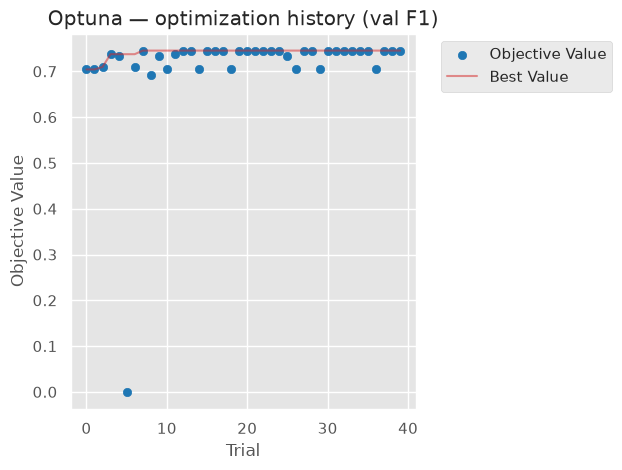

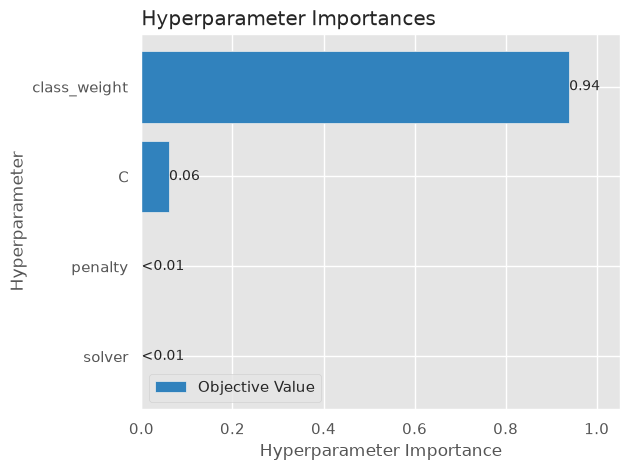

In [ ]:
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances)

ax = plot_optimization_history(pipeline.study)
ax.set_title('Optuna — optimization history (val F1)')
plt.tight_layout()

ax = plot_param_importances(pipeline.study)
plt.tight_layout()

### 5.2 Generalization gap across splits

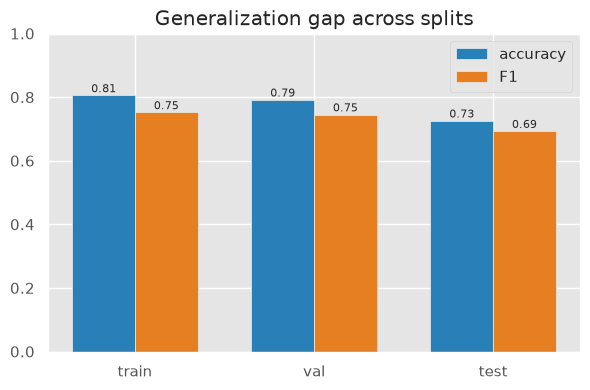

In [ ]:
est = state.model._estimator

splits = {'train': (X_train, y_train), 'val': (X_val, y_val), 'test': (X_test, y_test)}
acc_vals, f1_vals = [], []
for split_name, (Xs, ys) in splits.items():
    p = est.predict(Xs)
    acc_vals.append(accuracy(ys, p))
    f1_vals.append(f1_score(ys, p))

x = np.arange(len(splits)); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w/2, acc_vals, w, label='accuracy', color='#2980b9')
ax.bar(x + w/2, f1_vals,  w, label='F1',       color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(list(splits)); ax.set_ylim(0, 1)
ax.set_title('Generalization gap across splits')
for i in range(len(splits)):
    ax.text(i - w/2, acc_vals[i] + 0.01, f'{acc_vals[i]:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, f1_vals[i]  + 0.01, f'{f1_vals[i]:.2f}',  ha='center', fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

### 5.3 Classification diagnostics (held-out test set)

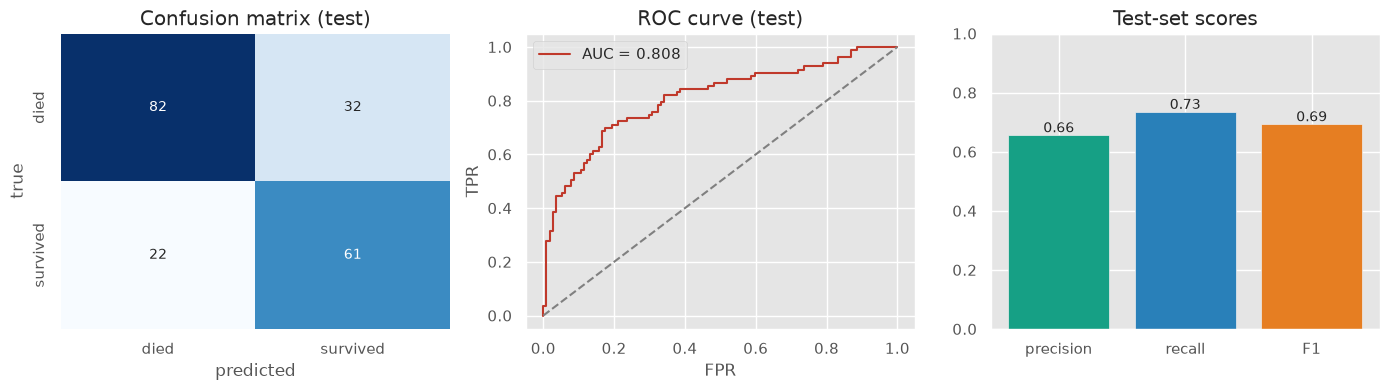

In [ ]:
proba_test = est.predict_proba(X_test)[:, 1]
pred_test  = est.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cm = confusion_matrix(y_test, pred_test, num_classes=2)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['died', 'survived'], yticklabels=['died', 'survived'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('Confusion matrix (test)')

fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)
ax = axes[1]; ax.plot(fpr, tpr, color='#c0392b', label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], ls='--', c='gray')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC curve (test)'); ax.legend()

pr, rc, f1v, _ = precision_recall_fscore_support(
    y_test, pred_test, average='binary')
ax = axes[2]
ax.bar(['precision', 'recall', 'F1'], [pr, rc, f1v],
       color=['#16a085', '#2980b9', '#e67e22'])
ax.set_ylim(0, 1); ax.set_title('Test-set scores')
for i, v in enumerate([pr, rc, f1v]):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.tight_layout(); plt.show()

### 5.4 Learning curve

Does more data help? Converging curves mean no; a wide gap means high variance.

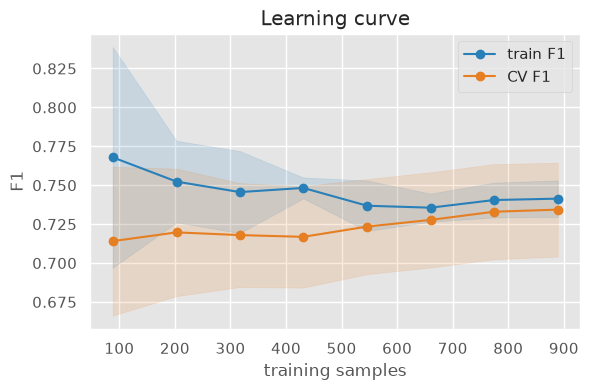

In [ ]:
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
best = pipeline.study.best_params
sizes, train_sc, val_sc = learning_curve(
    LogisticRegression(max_iter=2000, random_state=RNG_SEED, **best),
    X_tv, y_tv, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8), shuffle=True, random_state=RNG_SEED)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sizes, train_sc.mean(1), 'o-', color='#2980b9', label='train F1')
ax.fill_between(sizes,
                train_sc.mean(1) - train_sc.std(1),
                train_sc.mean(1) + train_sc.std(1), alpha=0.15, color='#2980b9')
ax.plot(sizes, val_sc.mean(1), 'o-', color='#e67e22', label='CV F1')
ax.fill_between(sizes,
                val_sc.mean(1) - val_sc.std(1),
                val_sc.mean(1) + val_sc.std(1), alpha=0.15, color='#e67e22')
ax.set_xlabel('training samples'); ax.set_ylabel('F1')
ax.set_title('Learning curve'); ax.legend()
plt.tight_layout(); plt.show()

## What happened?

1. **EDA** revealed `sex`, `pclass`, and family structure as strong signals, motivating
   `family_size`, `is_alone`, and `title` as engineered features.
2. **Three-way split** came for free by composing `train_test_split` twice.
3. **Optuna ran inside `build_model()`** — not loose in the notebook. The notebook
   only called `pipeline.run('train')`. The study is on `pipeline.study` for inspection.
4. The final model trained on `train`, evaluated on the **held-out test set** — never
   seen during tuning.
5. **Diagnostics** answered: is this model any good? and would more data help?

**Key insight:** Optuna is an implementation detail of *how* `build_model()` constructs
the model. The six-stage contract stays intact; the notebook stays clean.